<a href="https://colab.research.google.com/github/nehasmane2003-stack/MACHINE-LEARNING-Clg/blob/main/ASS_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task
Train and evaluate a Support Vector Machine (SVM) model on the Banknote Authentication Dataset to classify banknotes, including data preprocessing, model training, performance evaluation, and result visualization.

## Task
Train and evaluate a Support Vector Machine (SVM) model on the Banknote Authentication Dataset to classify banknotes, including data preprocessing, model training, performance evaluation, and result visualization.

## Load Dataset

### Subtask:
Load the Banknote Authentication Dataset. This step will also involve inspecting the data to understand its structure and check for any missing values.


In [ ]:
import pandas as pd

# Define the URL for the dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'

# Define column names based on the dataset description (found on the UCI ML Repository page)
column_names = [
    'variance_of_wavelet_transformed_image',
    'skewness_of_wavelet_transformed_image',
    'curtosis_of_wavelet_transformed_image',
    'entropy_of_image',
    'class' # 0 for authentic, 1 for inauthentic
]

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_url, names=column_names)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

# Check for any missing values in the DataFrame
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the dataset:
   variance_of_wavelet_transformed_image  \
0                                3.62160   
1                                4.54590   
2                                3.86600   
3                                3.45660   
4                                0.32924   

   skewness_of_wavelet_transformed_image  \
0                                 8.6661   
1                                 8.1674   
2                                -2.6383   
3                                 9.5228   
4                                -4.4552   

   curtosis_of_wavelet_transformed_image  entropy_of_image  class  
0                                -2.8073          -0.44699      0  
1                                -2.4586          -1.46210      0  
2                                 1.9242           0.10645      0  
3                                -4.0112          -3.59440      0  
4                                 4.5718          -0.98880      0  

DataFrame Information:
<class 'p

## Preprocess Data

### Subtask:
Perform necessary preprocessing steps on the dataset, such as scaling features, which is crucial for SVM performance. This will prepare the data for model training.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Display the first 5 rows of the scaled features and the target variable
print("First 5 rows of scaled features (X_scaled):")
print(X_scaled[:5])
print("\nFirst 5 rows of target variable (y):")
print(y.head())

First 5 rows of scaled features (X_scaled):
[[ 1.12180565  1.14945512 -0.97597007  0.35456135]
 [ 1.44706568  1.06445293 -0.89503626 -0.12876744]
 [ 1.20780971 -0.77735215  0.12221838  0.61807317]
 [ 1.06374236  1.29547754 -1.25539712 -1.14402883]
 [-0.03677175 -1.0870383   0.73673042  0.09658697]]

First 5 rows of target variable (y):
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


## Split Data

### Subtask:
Divide the preprocessed dataset into training and testing sets to evaluate the model's performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Print the shapes of the new datasets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1097, 4)
Shape of X_test: (275, 4)
Shape of y_train: (1097,)
Shape of y_test: (275,)


## Train SVM Model

### Subtask:
Train a Support Vector Machine (SVM) classifier using the training data. We will use a simple configuration to keep it easy.


In [ ]:
from sklearn.svm import SVC

# Instantiate an SVM classifier with a linear kernel and random_state for reproducibility
svm_model = SVC(random_state=42)

# Train the SVM model using the training data
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained SVM model's performance on the test set using appropriate metrics such as accuracy, precision, recall, and F1-score.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Confusion Matrix:
[[148   0]
 [  0 127]]


## Visualize Results

### Subtask:
Create a visualization, such as a confusion matrix or a plot showing decision boundaries (if applicable and easy to visualize with 2 features), to better understand the model's performance and classification. Ensure to provide legends.


**Reasoning**:
To visualize the confusion matrix, I will create a heatmap using `seaborn` and `matplotlib.pyplot` to clearly display the true positives, true negatives, false positives, and false negatives, making it easy to interpret the model's performance.



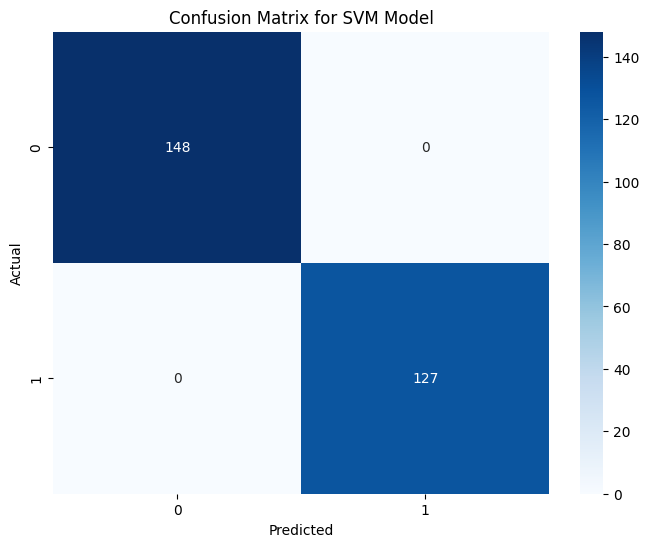

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Model')
plt.show()
